# Phase 1 EDA вЂ” Sudbury

Comprehensive Exploratory Data Analysis for the **Sudbury** seismic asset.
Covers: label audit, coordinate & shot gather analysis, waveform EDA,
amplitude/SNR statistics, label quality assessment, and visualization
example selection.

**This notebook builds on Phase 0.5.** Structural metadata (shapes, dtypes,
constant fields, total label counts) was already captured in
`results/00_environment_report.json` and is NOT re-computed here.

**Outputs:**
- `results/eda/<asset>_eda_report.json` вЂ” machine-readable EDA report
- `results/eda_plots/<asset>_*.png` вЂ” all diagnostic plots
- Contribution to `results/visualization_examples.json`

In [1]:
# ============================================================
# Cell 1 вЂ” Configuration & Setup
# ============================================================
# Change ONLY this variable to run on a different asset.
ASSET_NAME = "sudbury"

import sys, os, json, time, warnings
import numpy as np
import h5py
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for Colab
import matplotlib.pyplot as plt
import yaml

# Mount Drive (idempotent)
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Load project config
REPO_ROOT = "/content/drive/MyDrive/seismic-first-break-picking" if IN_COLAB else os.getcwd()
config_path = os.path.join(REPO_ROOT, "configs", "datasets.yaml")
with open(config_path) as f:
    CFG = yaml.safe_load(f)

# Derive paths from config
ASSET_META = CFG["asset_meta"][ASSET_NAME]
HDF5_PATH = os.path.join(REPO_ROOT, CFG["paths"]["extracted"], ASSET_META["extracted_file"])
EDA_PLOT_DIR = os.path.join(REPO_ROOT, CFG["paths"]["eda_plots"], ASSET_NAME)
EDA_JSON_DIR = os.path.join(REPO_ROOT, CFG["paths"]["eda_json"])
os.makedirs(EDA_PLOT_DIR, exist_ok=True)
os.makedirs(EDA_JSON_DIR, exist_ok=True)

# Import shared EDA utilities
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
from data.eda_utils import (
    open_hdf5, label_audit, compare_spare1_vs_fbt,
    compute_shot_gather_stats, compute_trace_amplitude_stats,
    compute_snr_proxy, reconstruct_shot_gather, label_quality_check,
    select_visualization_examples, make_json_safe,
    plot_label_histogram, plot_gather_size_distribution,
    plot_source_map, plot_offset_distribution,
    plot_shot_gather_with_fb, plot_amplitude_distribution,
    plot_snr_distribution, plot_fb_vs_offset,
)

print(f"Asset: {ASSET_NAME}")
print(f"HDF5 path: {HDF5_PATH}")
print(f"File exists: {os.path.exists(HDF5_PATH)}")
print(f"Plots dir: {EDA_PLOT_DIR}")
print(f"\nAsset metadata from config:")
for k, v in ASSET_META.items():
    print(f"  {k}: {v}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Asset: sudbury
HDF5 path: /content/drive/MyDrive/seismic-first-break-picking/data/extracted/sudbury.hdf5
File exists: True
Plots dir: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury

Asset metadata from config:
  raw_file: sudbury.hdf.xz
  extracted_file: sudbury.hdf5
  total_traces: 1810220
  samp_num: 1001
  samp_rate_us: 2000
  coord_scale: 100
  ht_scale: 10
  labeled_traces: 200338
  labeled_fraction: 0.1107
  time_window_ms: 2000


In [2]:
# ============================================================
# Cell 2 вЂ” Open HDF5 & Load Phase 0.5 Report
# ============================================================
f_handle, grp = open_hdf5(HDF5_PATH)
print(f"Opened: {HDF5_PATH}")
print(f"data_array shape: {grp['data_array'].shape}")
print(f"SPARE1 shape: {grp['SPARE1'].shape}")

# Load Phase 0.5 report for reference (avoid re-computation)
report_path = os.path.join(REPO_ROOT, "results", "00_environment_report.json")
with open(report_path) as rf:
    env_report = json.load(rf)
phase05 = env_report["hdf5_report"][ASSET_NAME]
print(f"\nPhase 0.5 verified: {phase05['status']}")
print(f"  Labeled traces: {phase05['labeled_traces']:,} / {phase05['total_traces']:,} "
      f"({phase05['labeled_fraction']*100:.1f}%)")
print(f"  Missing required keys: {phase05['missing_keys']}")

# Check for extra useful keys in this asset
available_extra = [k for k in CFG["extra_useful_keys"] if k in grp]
missing_extra = [k for k in CFG["extra_useful_keys"] if k not in grp]
print(f"\nExtra useful keys available: {available_extra}")
print(f"Extra useful keys missing: {missing_extra}")

Opened: /content/drive/MyDrive/seismic-first-break-picking/data/extracted/sudbury.hdf5
data_array shape: (1810220, 1001)
SPARE1 shape: (1810220, 1)

Phase 0.5 verified: PASS
  Labeled traces: 200,338 / 1,810,220 (11.1%)
  Missing required keys: []

Extra useful keys available: ['FIRST_BREAK_TIME', 'FIRST_BREAK_AMPLIT', 'FIRST_BREAK_VELOCITY', 'MODELLED_BREAK_TIME', 'OFFSET', 'OFFSET_FLT']
Extra useful keys missing: []


In [3]:
# ============================================================
# Cell 3 вЂ” Label Audit (Step 1.3)
# ============================================================
print(f"=== Label Audit: {ASSET_NAME} ===")
samp_rate_us = ASSET_META["samp_rate_us"]
samp_num = ASSET_META["samp_num"]

label_result, fb_values = label_audit(grp, samp_rate_us, samp_num)

print(f"\n--- Label Counts ---")
print(f"  Total traces: {label_result['total_traces']:,}")
print(f"  SPARE1 == 0:  {label_result['count_spare1_zero']:,}")
print(f"  SPARE1 == -1: {label_result['count_spare1_neg1']:,}")
print(f"  Other negative: {label_result['count_other_negative']:,}")
print(f"  Labeled (>0): {label_result['count_labeled']:,} ({label_result['labeled_fraction']*100:.2f}%)")

print(f"\n--- Label Quality Flags ---")
print(f"  Trace duration: {label_result['trace_duration_ms']:.1f} ms")
print(f"  Out-of-bounds labels (> duration): {label_result['count_oob_labels']}")
print(f"  Suspicious early labels (< 1 sample): {label_result['count_suspicious_early']}")

if label_result["fb_time_ms"]:
    fb_stats = label_result["fb_time_ms"]
    print(f"\n--- First Break Time Statistics (ms) ---")
    print(f"  Min:    {fb_stats['min']:.1f}")
    print(f"  Max:    {fb_stats['max']:.1f}")
    print(f"  Mean:   {fb_stats['mean']:.1f}")
    print(f"  Median: {fb_stats['median']:.1f}")
    print(f"  Std:    {fb_stats['std']:.1f}")
    print(f"  P5:     {fb_stats['p5']:.1f}")
    print(f"  P25:    {fb_stats['p25']:.1f}")
    print(f"  P75:    {fb_stats['p75']:.1f}")
    print(f"  P95:    {fb_stats['p95']:.1f}")

# Plot label histogram
if len(fb_values) > 0:
    plot_label_histogram(fb_values, ASSET_NAME,
                         os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_fb_histogram.png"))
    # Also show inline
    plt.figure(figsize=(10, 4))
    plt.hist(fb_values, bins=150, color="steelblue", edgecolor="none", alpha=0.8)
    plt.xlabel("First Break Time (ms)")
    plt.ylabel("Count")
    plt.title(f"{ASSET_NAME} вЂ” FB Time Distribution")
    plt.axvline(np.median(fb_values), color="red", linestyle="--",
                label=f"median={np.median(fb_values):.0f} ms")
    plt.legend()
    plt.tight_layout()
    plt.show()

=== Label Audit: sudbury ===

--- Label Counts ---
  Total traces: 1,810,220
  SPARE1 == 0:  1,609,882
  SPARE1 == -1: 0
  Other negative: 0
  Labeled (>0): 200,338 (11.07%)

--- Label Quality Flags ---
  Trace duration: 2000.0 ms
  Out-of-bounds labels (> duration): 0
  Suspicious early labels (< 1 sample): 0

--- First Break Time Statistics (ms) ---
  Min:    10.0
  Max:    599.0
  Mean:   169.7
  Median: 162.0
  Std:    71.3
  P5:     67.0
  P25:    121.0
  P75:    206.0
  P95:    307.0
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_fb_histogram.png


In [4]:
# ============================================================
# Cell 4 вЂ” SPARE1 vs FIRST_BREAK_TIME Comparison
# ============================================================
print(f"=== SPARE1 vs FIRST_BREAK_TIME: {ASSET_NAME} ===")
fbt_comparison = compare_spare1_vs_fbt(grp)

if fbt_comparison is None:
    print("FIRST_BREAK_TIME key not present in this asset вЂ” skipping comparison.")
elif fbt_comparison.get("n_both_labeled", 0) == 0:
    print("FIRST_BREAK_TIME present but no overlapping labeled traces with SPARE1.")
else:
    print(f"  Both labeled: {fbt_comparison['n_both_labeled']:,}")
    print(f"  Exact match: {fbt_comparison['n_exact_match']:,} "
          f"({fbt_comparison['exact_match_fraction']*100:.2f}%)")
    print(f"  Diff mean: {fbt_comparison['diff_mean']:.4f} ms")
    print(f"  Diff std: {fbt_comparison['diff_std']:.4f} ms")
    print(f"  Diff |max|: {fbt_comparison['diff_abs_max']:.4f} ms")
    print(f"  Diff median: {fbt_comparison['diff_median']:.4f} ms")
    if fbt_comparison['exact_match_fraction'] > 0.99:
        print("  в†’ SPARE1 and FIRST_BREAK_TIME are effectively identical.")
    else:
        print("  в†’ WARNING: SPARE1 and FIRST_BREAK_TIME differ! Investigate.")

=== SPARE1 vs FIRST_BREAK_TIME: sudbury ===
FIRST_BREAK_TIME present but no overlapping labeled traces with SPARE1.


=== Shot Gather Analysis: sudbury ===
  Reading metadata arrays...
  Found 1,016 unique shots
  Computed in 148.6s

--- Shot Gather Summary ---
  Total unique shots: 1,016
  SHOTID == SHOT_PEG: False
  Traces per shot:
    Min: 670  Max: 1983  Mean: 1781.7  Median: 1763
    P5: 1328  P95: 1983  Std: 223.8
  Offset range: 31622.8 вЂ” 71556769.5
  Label coverage per shot:
    Fully labeled shots: 0
    Partially labeled:   715
    Zero-label shots:    301
  Geographic extent:
    X: 4577475000.0 вЂ” 4647828100.0
    Y: 51479425000.0 вЂ” 51548550000.0
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_gather_sizes.png
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_source_map.png
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_offset_dist.png
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_fb_vs_offset.png


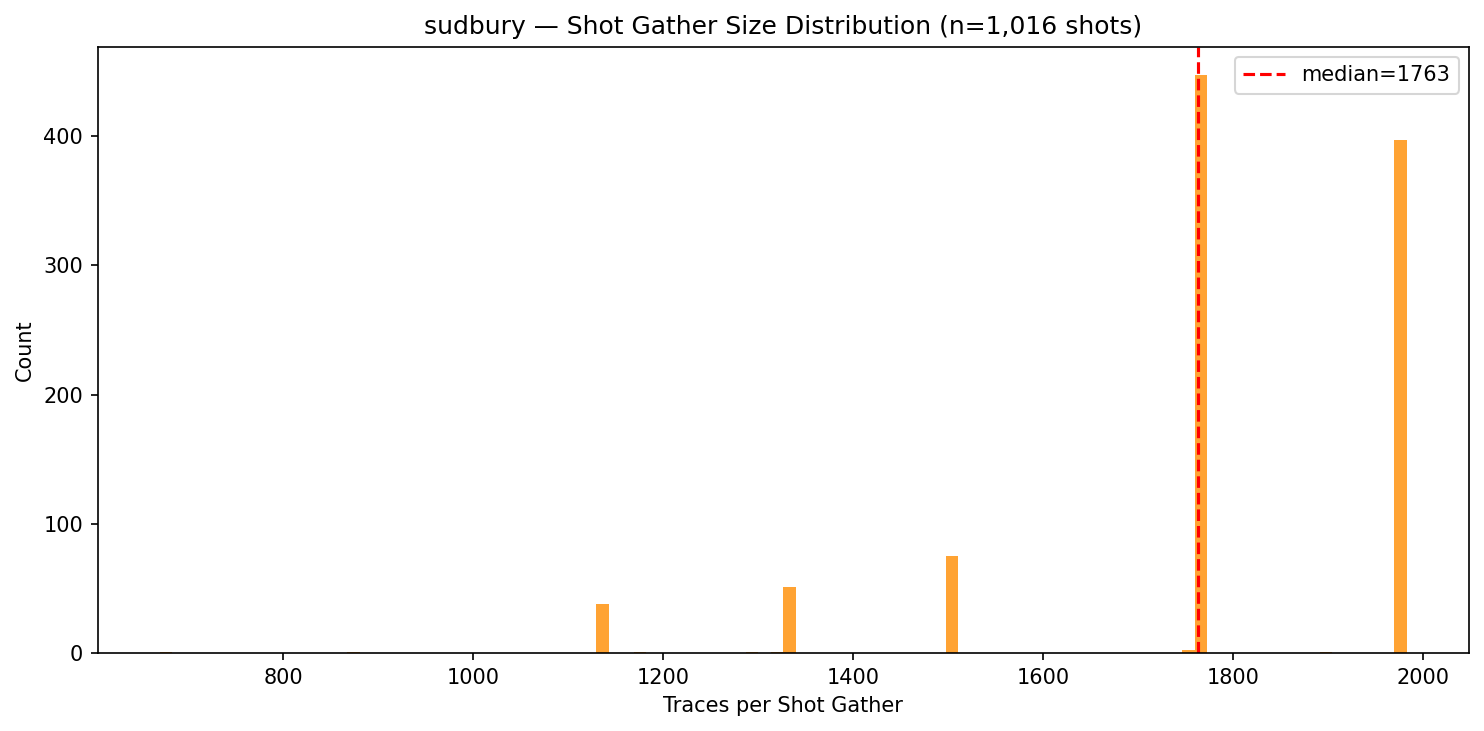

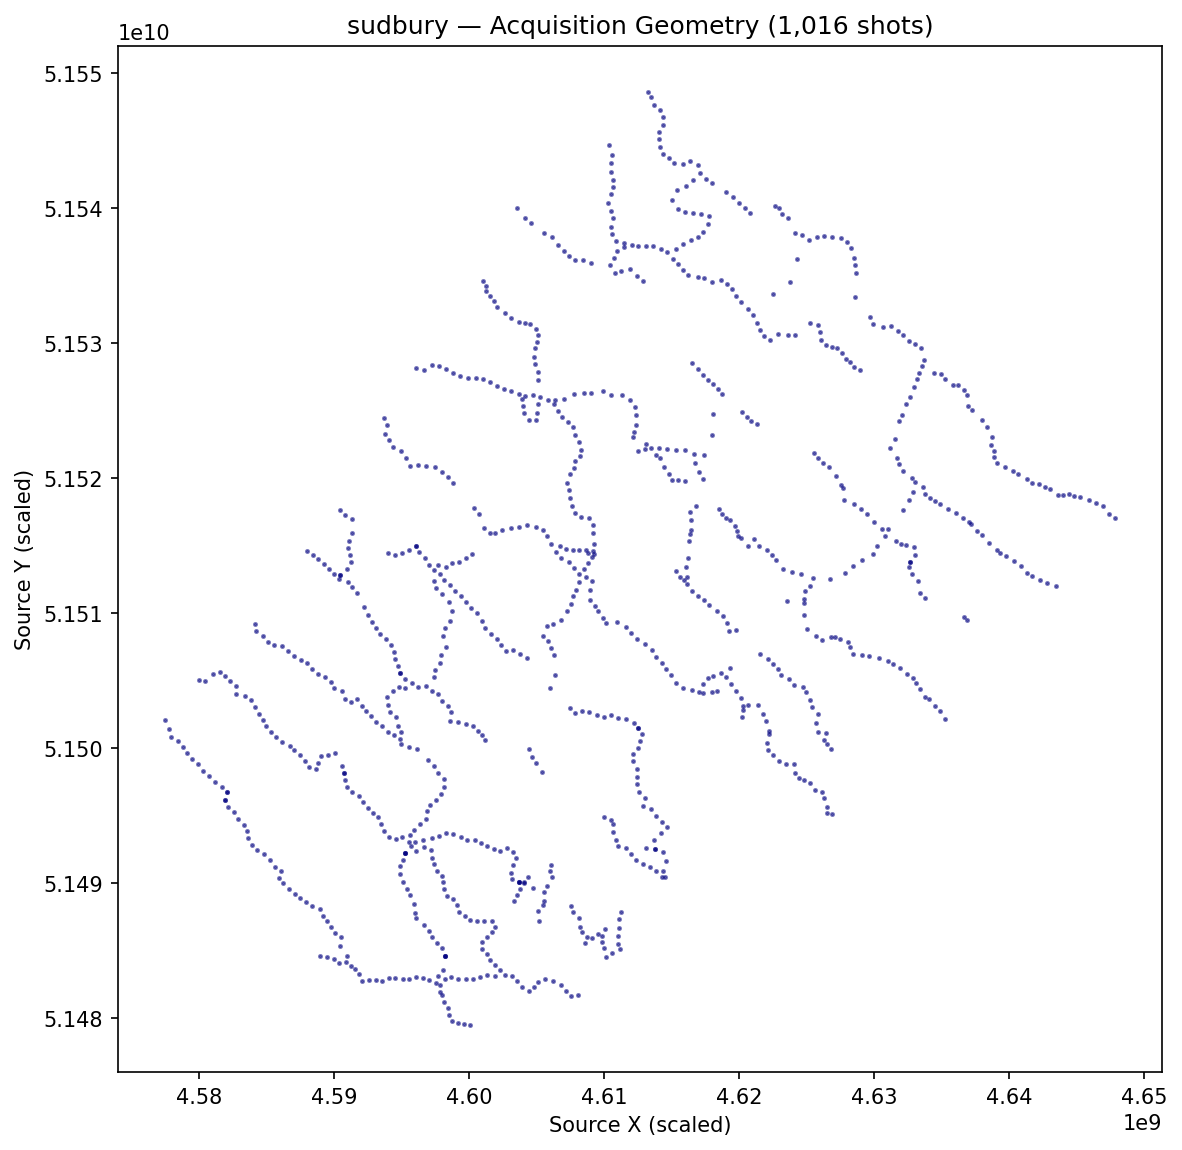

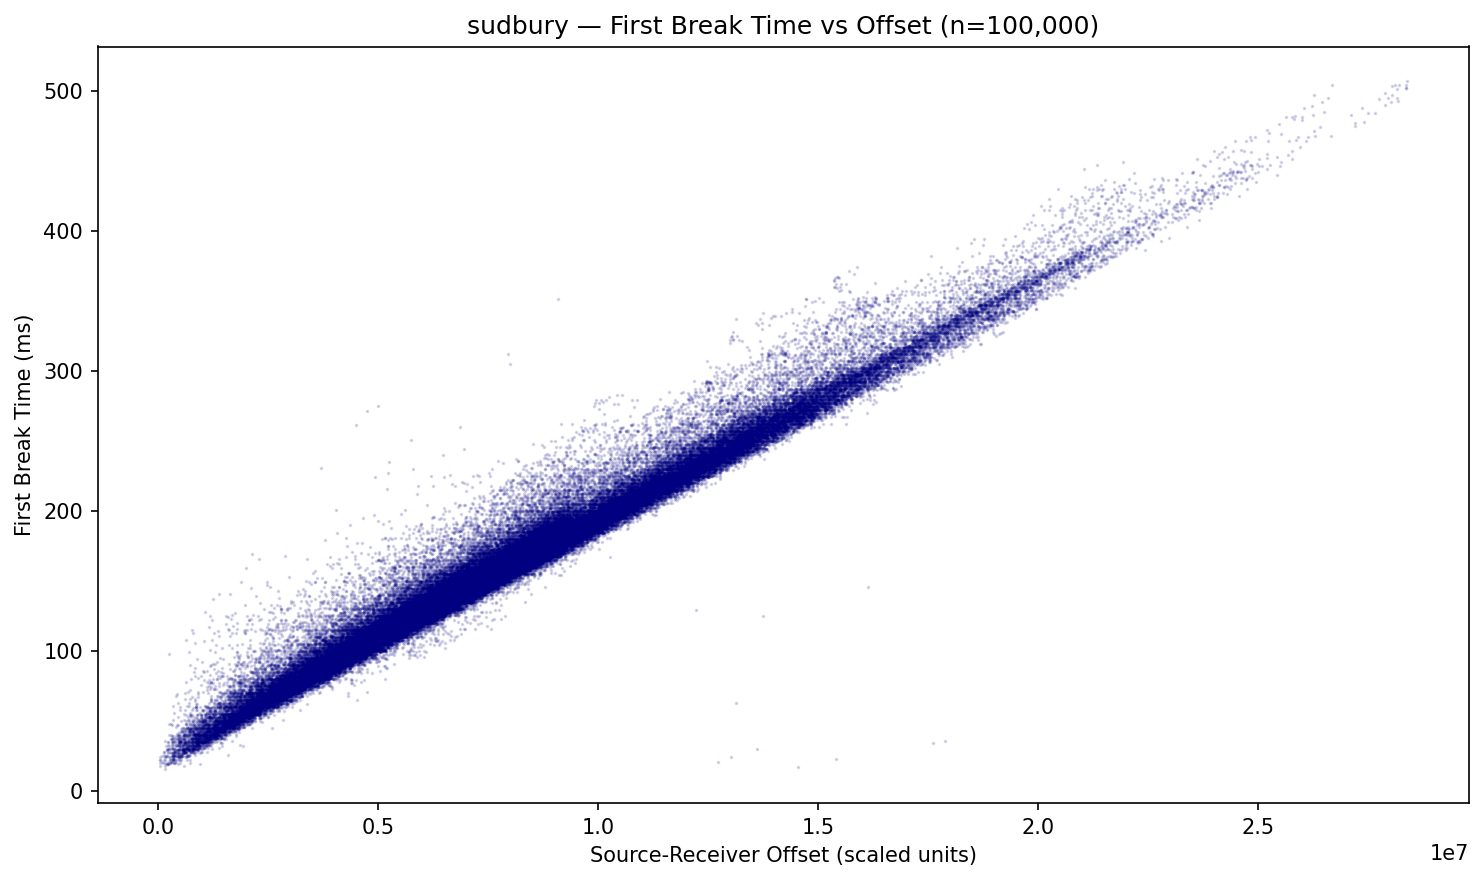

In [5]:
# ============================================================
# Cell 5 вЂ” Coordinate Analysis & Shot Gather Stats (Step 1.4)
# ============================================================
print(f"=== Shot Gather Analysis: {ASSET_NAME} ===")
t0 = time.time()

coord_scale = ASSET_META["coord_scale"]
ht_scale = ASSET_META["ht_scale"]

shot_stats = compute_shot_gather_stats(grp, coord_scale, ht_scale)
elapsed = time.time() - t0
print(f"  Computed in {elapsed:.1f}s")

print(f"\n--- Shot Gather Summary ---")
print(f"  Total unique shots: {shot_stats['n_shots']:,}")
print(f"  SHOTID == SHOT_PEG: {shot_stats['shotid_vs_shotpeg_identical']}")
gs = shot_stats['gather_size']
print(f"  Traces per shot:")
print(f"    Min: {gs['min']}  Max: {gs['max']}  Mean: {gs['mean']:.1f}  Median: {gs['median']:.0f}")
print(f"    P5: {gs['p5']:.0f}  P95: {gs['p95']:.0f}  Std: {gs['std']:.1f}")
osr = shot_stats['offset_range']
print(f"  Offset range: {osr['global_min']:.1f} вЂ” {osr['global_max']:.1f}")
lcps = shot_stats['label_coverage_per_shot']
print(f"  Label coverage per shot:")
print(f"    Fully labeled shots: {lcps['n_full_label_shots']:,}")
print(f"    Partially labeled:   {lcps['n_partial_label_shots']:,}")
print(f"    Zero-label shots:    {lcps['n_zero_label_shots']:,}")
geo = shot_stats['geographic_extent']
print(f"  Geographic extent:")
print(f"    X: {geo['src_x_min']:.1f} вЂ” {geo['src_x_max']:.1f}")
print(f"    Y: {geo['src_y_min']:.1f} вЂ” {geo['src_y_max']:.1f}")

# Plots
plot_gather_size_distribution(
    shot_stats["_gather_sizes"], ASSET_NAME,
    os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_gather_sizes.png"))

plot_source_map(
    shot_stats["_src_x"], shot_stats["_src_y"], ASSET_NAME,
    os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_source_map.png"))

plot_offset_distribution(
    shot_stats["_offsets"], ASSET_NAME,
    os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_offset_dist.png"))

# FB time vs offset scatter
plot_fb_vs_offset(
    shot_stats["_offsets"], shot_stats["_spare1"].astype(np.float64),
    ASSET_NAME,
    os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_fb_vs_offset.png"))

# Show key plots inline
from IPython.display import Image, display
for fname in [f"{ASSET_NAME}_gather_sizes.png", f"{ASSET_NAME}_source_map.png",
              f"{ASSET_NAME}_fb_vs_offset.png"]:
    fpath = os.path.join(EDA_PLOT_DIR, fname)
    if os.path.exists(fpath):
        display(Image(filename=fpath))

=== Amplitude Analysis: sudbury ===
  Sampling 50,000 traces for amplitude analysis...
  Computed in 97.6s

--- Amplitude Stats (from 50,000 sampled traces) ---
  Max |Amplitude|:  min=0.000341  max=127.999985  mean=0.504945  median=0.092555
  RMS Amplitude:    min=0.000110  max=32.941963  mean=0.067722  median=0.017214
  Dead traces (max<1e-10):  0 (0.000%)
  Clipped traces (>10 at rail): 0 (0.000%)
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_amplitude_dist.png


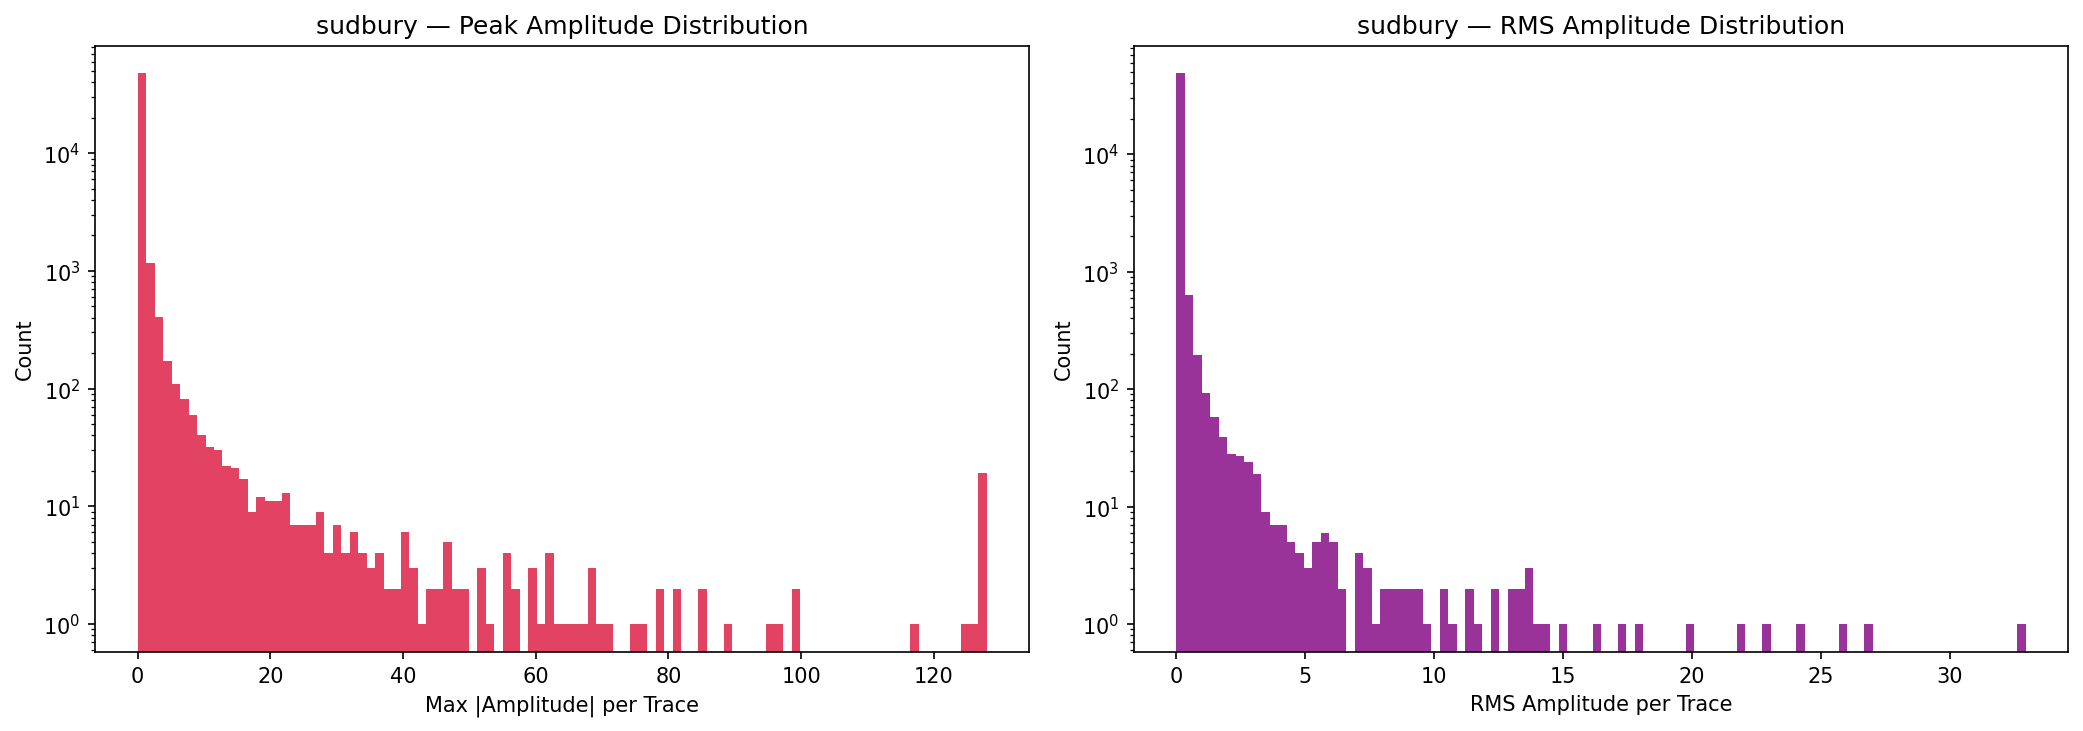

In [6]:
# ============================================================
# Cell 6 вЂ” Waveform Amplitude Analysis (Step 1.5)
# ============================================================
print(f"=== Amplitude Analysis: {ASSET_NAME} ===")
t0 = time.time()
amp_stats = compute_trace_amplitude_stats(grp, n_sample_traces=50000)
elapsed = time.time() - t0
print(f"  Computed in {elapsed:.1f}s")

print(f"\n--- Amplitude Stats (from {amp_stats['n_sampled']:,} sampled traces) ---")
amax = amp_stats['amplitude_max']
print(f"  Max |Amplitude|:  min={amax['min']:.6f}  max={amax['max']:.6f}  "
      f"mean={amax['mean']:.6f}  median={amax['median']:.6f}")
arms = amp_stats['amplitude_rms']
print(f"  RMS Amplitude:    min={arms['min']:.6f}  max={arms['max']:.6f}  "
      f"mean={arms['mean']:.6f}  median={arms['median']:.6f}")
print(f"  Dead traces (max<1e-10):  {amp_stats['dead_traces_in_sample']} "
      f"({amp_stats['dead_fraction_estimate']*100:.3f}%)")
print(f"  Clipped traces (>10 at rail): {amp_stats['clipped_traces_in_sample']} "
      f"({amp_stats['clipped_fraction_estimate']*100:.3f}%)")

# Plot
plot_amplitude_distribution(
    amp_stats["_amplitudes_max"], amp_stats["_amplitudes_rms"],
    ASSET_NAME,
    os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_amplitude_dist.png"))

display(Image(filename=os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_amplitude_dist.png")))

=== SNR Proxy Analysis: sudbury ===
  Finding labeled traces for SNR computation...
  Computed in 10.4s

--- SNR Proxy (log10) from 10,000 traces ---
  Mean:   1.779
  Median: 1.796
  Std:    0.734
  P5:     0.496
  P95:    2.937
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_snr_dist.png


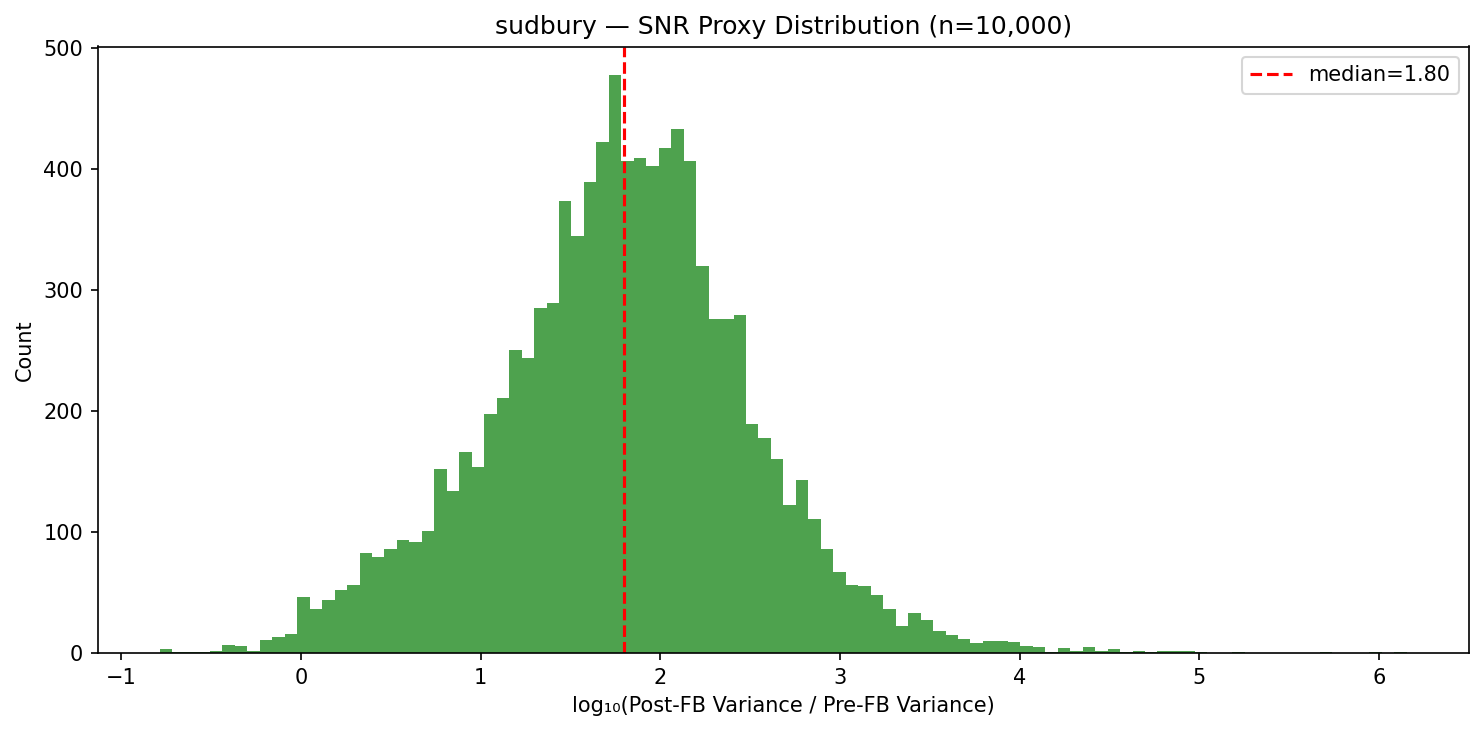

In [7]:
# ============================================================
# Cell 7 вЂ” SNR Proxy Analysis (Step 1.5 continued)
# ============================================================
print(f"=== SNR Proxy Analysis: {ASSET_NAME} ===")
t0 = time.time()
snr_result = compute_snr_proxy(grp, samp_rate_us, n_sample=10000)
elapsed = time.time() - t0
print(f"  Computed in {elapsed:.1f}s")

if snr_result["snr_available"]:
    snr_s = snr_result["snr_log10"]
    print(f"\n--- SNR Proxy (log10) from {snr_result['n_computed']:,} traces ---")
    print(f"  Mean:   {snr_s['mean']:.3f}")
    print(f"  Median: {snr_s['median']:.3f}")
    print(f"  Std:    {snr_s['std']:.3f}")
    print(f"  P5:     {snr_s['p5']:.3f}")
    print(f"  P95:    {snr_s['p95']:.3f}")

    plot_snr_distribution(
        snr_result["_snr_values"], ASSET_NAME,
        os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_snr_dist.png"))
    display(Image(filename=os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_snr_dist.png")))
else:
    print("  No labeled traces available for SNR computation.")

In [8]:
# ============================================================
# Cell 8 вЂ” Shot Gather Visualization (Step 1.5 continued)
# ============================================================
# Visualize 5 shot gathers at different offset ranges
print(f"=== Shot Gather Visualization: {ASSET_NAME} ===")

n_shots = shot_stats["n_shots"]
gather_sizes = shot_stats["_gather_sizes"]
label_fracs = shot_stats["_gather_label_fracs"]
unique_shots = shot_stats["_unique_shots"]

# Select 5 well-labeled gathers with varying sizes
good_shots = np.where((label_fracs > 0.5) & (gather_sizes >= 20))[0]
if len(good_shots) >= 5:
    # Pick from different parts of the size distribution
    sorted_good = good_shots[np.argsort(gather_sizes[good_shots])]
    n_good = len(sorted_good)
    pick_indices = [0, n_good//4, n_good//2, 3*n_good//4, n_good-1]
    selected = [sorted_good[i] for i in pick_indices]
else:
    selected = good_shots[:min(5, len(good_shots))]

for i, shot_idx in enumerate(selected):
    shot_id = int(unique_shots[shot_idx])
    print(f"\n  Rendering shot {i+1}/5: ID={shot_id}, "
          f"size={gather_sizes[shot_idx]}, label_frac={label_fracs[shot_idx]:.2f}")

    gather_2d, offsets, fb_times = reconstruct_shot_gather(
        grp, shot_stats, shot_idx, samp_rate_us)

    save_name = f"{ASSET_NAME}_gather_{i+1}_shot{shot_id}.png"
    plot_shot_gather_with_fb(
        gather_2d, offsets, fb_times, samp_rate_us,
        shot_id, ASSET_NAME,
        os.path.join(EDA_PLOT_DIR, save_name))

    display(Image(filename=os.path.join(EDA_PLOT_DIR, save_name)))

=== Shot Gather Visualization: sudbury ===


In [9]:
# ============================================================
# Cell 9 вЂ” Label Quality Assessment (Step 1.7)
# ============================================================
print(f"=== Label Quality Assessment: {ASSET_NAME} ===")
t0 = time.time()
label_quality = label_quality_check(grp, shot_stats, samp_rate_us,
                                    n_shots_to_check=200)
elapsed = time.time() - t0
print(f"  Computed in {elapsed:.1f}s")

if label_quality["label_quality_available"]:
    print(f"\n--- Mispick Analysis ---")
    print(f"  Eligible shots (в‰Ґ10 labeled traces): {label_quality['n_eligible_shots']:,}")
    print(f"  Shots checked: {label_quality['n_shots_checked']}")
    print(f"  Total labels checked: {label_quality['total_labeled_checked']:,}")
    print(f"  Outliers (>3Пѓ from polynomial fit): {label_quality['total_outliers_3sigma']:,}")
    print(f"  Outlier fraction: {label_quality['outlier_fraction']*100:.3f}%")
    rs = label_quality['residual_stats']
    print(f"  Residual stats:")
    print(f"    Mean: {rs['mean']:.3f} ms")
    print(f"    Std:  {rs['std']:.3f} ms")
    print(f"    |Median|: {rs['abs_median']:.3f} ms")
    print(f"    |P95|: {rs['abs_p95']:.3f} ms")
else:
    print(f"  Could not assess: {label_quality.get('reason', 'unknown')}")

=== Label Quality Assessment: sudbury ===
  Computed in 0.2s

--- Mispick Analysis ---
  Eligible shots (в‰Ґ10 labeled traces): 715
  Shots checked: 200
  Total labels checked: 55,085
  Outliers (>3Пѓ from polynomial fit): 619
  Outlier fraction: 1.124%
  Residual stats:
    Mean: 0.000 ms
    Std:  6.788 ms
    |Median|: 3.203 ms
    |P95|: 12.636 ms


In [10]:
# ============================================================
# Cell 10 вЂ” Select Visualization Examples (Meta Plan contract)
# ============================================================
print(f"=== Visualization Example Selection: {ASSET_NAME} ===")
viz_examples = select_visualization_examples(
    grp, shot_stats, snr_result, ASSET_NAME)

if viz_examples:
    for ex in viz_examples:
        print(f"  {ex['difficulty']:6s}: shot_id={ex['shot_id']}, "
              f"size={ex['gather_size']}, label_frac={ex['label_fraction']:.2f}")

    # Render the 3 examples
    for ex in viz_examples:
        gather_2d, offsets, fb_times = reconstruct_shot_gather(
            grp, shot_stats, ex["shot_array_index"], samp_rate_us)
        save_name = f"{ASSET_NAME}_vizex_{ex['difficulty']}_shot{ex['shot_id']}.png"
        plot_shot_gather_with_fb(
            gather_2d, offsets, fb_times, samp_rate_us,
            ex["shot_id"], f"{ASSET_NAME} ({ex['difficulty']})",
            os.path.join(EDA_PLOT_DIR, save_name))
        display(Image(filename=os.path.join(EDA_PLOT_DIR, save_name)))
else:
    print("  Could not select visualization examples.")

Output hidden; open in https://colab.research.google.com to view.

In [11]:
# ============================================================
# Cell 11 вЂ” Representative Trace Plots (Step 1.5)
# ============================================================
# Plot 8 individual traces: 4 labeled, 4 unlabeled
print(f"=== Representative Trace Plots: {ASSET_NAME} ===")

spare1_all = shot_stats["_spare1"]
labeled_mask = (spare1_all > 0) & (spare1_all != -1)
unlabeled_mask = ~labeled_mask

labeled_idx = np.where(labeled_mask)[0]
unlabeled_idx = np.where(unlabeled_mask)[0]

rng = np.random.RandomState(42)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
dt_ms = samp_rate_us / 1000.0

# Top row: labeled traces
sample_labeled = rng.choice(labeled_idx, size=min(4, len(labeled_idx)), replace=False)
for col, idx in enumerate(sample_labeled):
    idx = int(idx)
    trace = grp["data_array"][idx]
    fb_ms = float(spare1_all[idx])
    time_axis = np.arange(len(trace)) * dt_ms
    ax = axes[0, col]
    ax.plot(time_axis, trace, linewidth=0.5, color="steelblue")
    ax.axvline(fb_ms, color="red", linestyle="--", linewidth=1.5,
               label=f"FB={fb_ms:.0f}ms")
    ax.set_title(f"Labeled trace {idx}", fontsize=9)
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.legend(fontsize=7)

# Bottom row: unlabeled traces
if len(unlabeled_idx) >= 4:
    sample_unlabeled = rng.choice(unlabeled_idx, size=4, replace=False)
    for col, idx in enumerate(sample_unlabeled):
        idx = int(idx)
        trace = grp["data_array"][idx]
        time_axis = np.arange(len(trace)) * dt_ms
        ax = axes[1, col]
        ax.plot(time_axis, trace, linewidth=0.5, color="gray")
        ax.set_title(f"Unlabeled trace {idx}", fontsize=9)
        ax.set_xlabel("Time (ms)", fontsize=8)

fig.suptitle(f"{ASSET_NAME} вЂ” Representative Traces", fontsize=12)
fig.tight_layout()
save_path = os.path.join(EDA_PLOT_DIR, f"{ASSET_NAME}_representative_traces.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {save_path}")

=== Representative Trace Plots: sudbury ===
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury/sudbury_representative_traces.png


In [12]:
# ============================================================
# Cell 12 вЂ” Save EDA Report & Cleanup
# ============================================================
print(f"=== Saving EDA Report: {ASSET_NAME} ===")

eda_report = {
    "asset": ASSET_NAME,
    "label_audit": make_json_safe(label_result),
    "spare1_vs_fbt": make_json_safe(fbt_comparison) if fbt_comparison else None,
    "shot_gather_stats": make_json_safe(shot_stats),
    "amplitude_stats": make_json_safe(amp_stats),
    "snr_proxy": make_json_safe(snr_result),
    "label_quality": make_json_safe(label_quality),
    "visualization_examples": make_json_safe(viz_examples),
}

report_path = os.path.join(EDA_JSON_DIR, f"{ASSET_NAME}_eda_report.json")
with open(report_path, "w") as f:
    json.dump(eda_report, f, indent=2)
print(f"  Saved: {report_path}")

# Close HDF5
f_handle.close()
print(f"  HDF5 file closed.")

# List all generated plots
plots = sorted(os.listdir(EDA_PLOT_DIR))
print(f"\n  Generated {len(plots)} plots in {EDA_PLOT_DIR}:")
for p in plots:
    sz = os.path.getsize(os.path.join(EDA_PLOT_DIR, p))
    print(f"    {p}  ({sz/1024:.0f} KB)")

print(f"\n{'='*60}")
print(f"PHASE 1 EDA COMPLETE вЂ” {ASSET_NAME.upper()}")
print(f"{'='*60}")

=== Saving EDA Report: sudbury ===
  Saved: /content/drive/MyDrive/seismic-first-break-picking/results/eda/sudbury_eda_report.json
  HDF5 file closed.

  Generated 11 plots in /content/drive/MyDrive/seismic-first-break-picking/results/eda_plots/sudbury:
    sudbury_amplitude_dist.png  (48 KB)
    sudbury_fb_histogram.png  (43 KB)
    sudbury_fb_vs_offset.png  (247 KB)
    sudbury_gather_sizes.png  (40 KB)
    sudbury_offset_dist.png  (43 KB)
    sudbury_representative_traces.png  (487 KB)
    sudbury_snr_dist.png  (41 KB)
    sudbury_source_map.png  (73 KB)
    sudbury_vizex_easy_shot243.png  (3501 KB)
    sudbury_vizex_hard_shot122.png  (3396 KB)
    sudbury_vizex_medium_shot866.png  (4453 KB)

PHASE 1 EDA COMPLETE вЂ” SUDBURY
